## Load the tokenizer

In [8]:
import sys
sys.path.append("/content/personalize_chatbot")


In [9]:
%pip install -U --force-reinstall "torch==2.5.1" --index-url https://download.pytorch.org/whl/cu121



Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (780.4 MB)
ERROR: Operation cancelled by user


In [10]:
# install your repo in editable mode
%pip install -e /content/personalize_chatbot

# now this will work (if __init__.py exports it; otherwise use minbpe.basic)
from minbpe.basic import BasicTokenizer   # safest
tok = BasicTokenizer()
tok.load(model_file="/content/personalize_chatbot/output/tokenizer/my_tokenizer.model")


Obtaining file:///content/personalize_chatbot
ERROR: file:///content/personalize_chatbot does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [11]:
from minbpe.basic import BasicTokenizer

tokenizer = BasicTokenizer()
tokenizer.load(model_file="/content/personalize_chatbot/output/tokenizer/my_tokenizer.model")



def get_vocab_size(tokenizer: BasicTokenizer) -> int:
    vocab = tokenizer.vocab
    special_tokens = tokenizer.special_tokens

    return len(vocab) + len(special_tokens)

## Create the model

In [12]:
import torch
import torch, importlib.util
print(torch.__version__)
print("has inductor:", importlib.util.find_spec("torch._inductor") is not None)
  # should now work
torch.manual_seed(3647)

2.5.1+cu121
has inductor: True


In [14]:

from transformer.model import GPTLanguageModel



block_size = 256
n_embd = 512
n_head = 8
n_layer = 4
dropout = 0.2
batch_size = 64
vocab_size = get_vocab_size(tokenizer)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
    device=device
).to(device)


print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

13.795338 M parameters


In [15]:
import os, sys, pathlib, glob
print("CWD:", os.getcwd())
print("Python:", sys.version)
print("First few sys.path entries:", sys.path[:5])
print("Does mbipi exist here?", glob.glob("**/mbipi*", recursive=True)[:10])


CWD: /content
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
First few sys.path entries: ['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload']
Does mbipi exist here? []


## Data preparation

### 1. Load the data

In [16]:
import requests

# 1. Load text from GitHub RAW file
url = "https://raw.githubusercontent.com/UruslKhan21/personalize_chatbot/main/output/combined_text.txt"
text_sequence = requests.get(url).text

# 2. Encode using your tokenizer
encoded_text_sequence = tokenizer.encode(text_sequence)

# 3. Check encoded length
len(encoded_text_sequence)


95379

### 2. Split it into train and test

In [17]:
data = torch.tensor(encoded_text_sequence, dtype=torch.long)
split_index = int(0.9 * len(data))
train_data = data[:split_index]
val_data = data[split_index:]

### 3. Data loader

In [18]:
from typing import Tuple
from torch.utils.data import Dataset, DataLoader


class TextDataset(Dataset):
    def __init__(self, data: torch.Tensor, block_size: int) -> None:
        if len(data) <= block_size:
            raise ValueError(
                f"The length of the data ({len(data)}) must be greater than the block_size ({block_size})."
            )

        self.data = data
        self.block_size = block_size

    def __len__(self) -> int:
        return len(self.data) - self.block_size

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        x = self.data[index : index + self.block_size]
        y = self.data[index + 1 : index + self.block_size + 1]
        return x, y


def get_dataloaders(
    train_data: torch.Tensor,
    val_data: torch.Tensor,
    block_size: int,
    batch_size: int,
    device: torch.device,
) -> Tuple[DataLoader, DataLoader]:
    train_dataset = TextDataset(train_data.to(device), block_size)
    val_dataset = TextDataset(val_data.to(device), block_size)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    return train_loader, val_loader

In [19]:
train_loader, val_loader = get_dataloaders(
    train_data=train_data,
    val_data=val_data,
    block_size=block_size,
    batch_size=batch_size,
    device=device,
)
x, y = next(iter(train_loader))
x.shape, y.shape

(torch.Size([64, 256]), torch.Size([64, 256]))

### 4. Training

In [20]:
from typing import Dict


@torch.no_grad()
def estimate_loss(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    eval_iters: int
) -> Dict[str, float]:
    output = {}
    model.eval()

    for split, loader in [('train', train_loader), ('val', val_loader)]:
        losses = torch.zeros(eval_iters)
        for i, (x, y) in enumerate(loader):
            if i >= eval_iters:
                break
            with torch.no_grad():
                _, loss = model(x, y)
            losses[i] = loss.item()
        output[split] = losses.mean().item()

    model.train()
    return output

In [21]:
def save_checkpoint(
    model: GPTLanguageModel,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    loss: float,
    file_path: str = "checkpoint.pth"
) -> None:
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }
    torch.save(checkpoint, file_path)

In [22]:
import torch._dynamo
torch._dynamo.config.suppress_errors = True

max_iters = 1
eval_interval = 100
eval_iters = 200
learning_rate = 3e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
train_loader, val_loader = get_dataloaders(
    train_data=train_data,
    val_data=val_data,
    block_size=block_size,
    batch_size=batch_size,
    device=device
)

train_losses = []
val_losses = []

for iteration in range(max_iters):
    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        # Evaluation
        if batch_idx % eval_interval == 0 or batch_idx == len(train_loader) - 1:
            losses = estimate_loss(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                eval_iters=min(eval_iters, len(val_loader))
            )
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])

            print(
                f"iteration {iteration} / step {batch_idx}: "
                f"train loss {losses['train']:.4f}, "
                f"val loss {losses['val']:.4f}"
            )

        # Training step
        logits, loss = model(x_batch, y_batch)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    # Save checkpoint
    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=iteration,
        loss=loss.item(),
        file_path=f"../output/pre_training/run_4/checkpoint_{iteration}.pth"
    )

iteration 0 / step 0: train loss 7.0200, val loss 7.0569
iteration 0 / step 100: train loss 4.6395, val loss 5.0109
iteration 0 / step 200: train loss 3.4201, val loss 3.1054
iteration 0 / step 300: train loss 2.4989, val loss 2.2265
iteration 0 / step 400: train loss 1.3691, val loss 1.6489
iteration 0 / step 500: train loss 0.6069, val loss 1.5535
iteration 0 / step 600: train loss 0.3152, val loss 1.5873
iteration 0 / step 700: train loss 0.2149, val loss 1.6458
iteration 0 / step 800: train loss 0.1686, val loss 1.6910
iteration 0 / step 900: train loss 0.1422, val loss 1.7299
iteration 0 / step 1000: train loss 0.1275, val loss 1.7580
iteration 0 / step 1100: train loss 0.1162, val loss 1.7823
iteration 0 / step 1200: train loss 0.1072, val loss 1.7948
iteration 0 / step 1300: train loss 0.0992, val loss 1.8120
iteration 0 / step 1337: train loss 0.0981, val loss 1.8227


RuntimeError: Parent directory ../output/pre_training/run_4 does not exist.

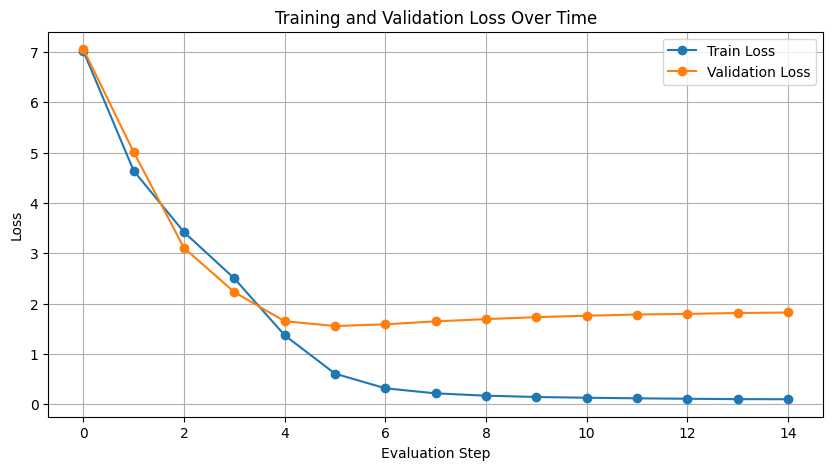

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

In [25]:
input_tokens = tokenizer.encode("happy birdthday")
input_tokens = torch.tensor(
    input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=100)

print(tokenizer.decode(output[0].tolist()))

happy birdthday? Ha Nuzhat Baji.vcf (file attached) Shalu mamu ko bola ha agar aap vo bol raha ha ki ek baar pata kark jana kaha par hoga or Kitana time lagaga Men pucha pr is baar aai hi nhi rhi h h udaipur to koi Delhi jayga bhi nhi... Vaa Limited
